In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [139]:
df = pd.read_csv('1-studyhours.csv')

In [140]:
df

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7
5,18.0,78.8
6,19.2,77.1
7,22.2,90.8
8,25.2,99.0
9,17.4,84.6


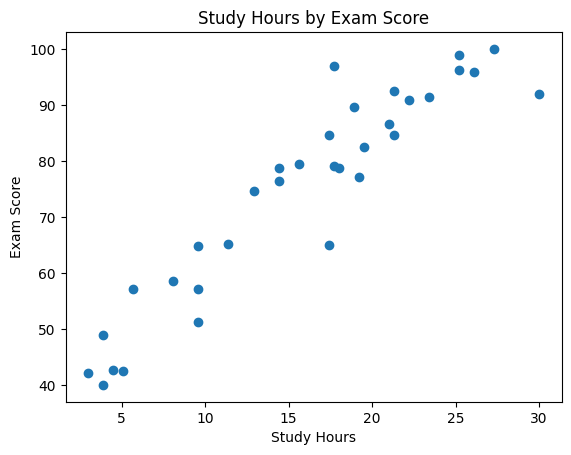

In [141]:
plt.scatter(x=df["Study Hours"],y=df["Exam Score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours by Exam Score")
plt.show()

In [142]:
# independent and dependent features

X = df[['Study Hours']] # çift parantez yaptığımızda X -> dataframe olarak gelir!
y = df["Exam Score"]

In [143]:
type(X)

pandas.core.frame.DataFrame

In [144]:
type(y) # burası OK. -> çıktı tek olacağı için series kalabilir. ama 'X' dataframe olarak kaydedilmeli! çünkü tek bir girdi olmak zorunda değil.

pandas.core.series.Series

In [145]:
# test - train split

In [146]:
from sklearn.model_selection import train_test_split

In [147]:
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size= 0.2, random_state=15)

# Bu kısım önemli!!! data'nın %20 sini test yapmak için kullan!!

In [148]:
y_test

25    42.4
14    86.6
30    91.5
16    57.2
24    51.2
20    49.0
19    84.7
Name: Exam Score, dtype: float64

In [149]:
y_train

18     64.9
1      57.1
2      42.7
32     89.6
6      77.1
3      65.1
29     82.4
26     64.8
9      84.6
4      78.7
28     79.1
10     92.4
27     79.5
13    100.0
17     74.7
15     97.0
22     76.5
31     96.2
11     95.9
7      90.8
0      40.0
23     42.2
5      78.8
12     92.0
21     58.5
8      99.0
Name: Exam Score, dtype: float64

In [150]:
# standardize the data set

In [151]:
from sklearn.preprocessing import StandardScaler

In [152]:
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [153]:
# balanced feature values
# gradient descent'in daha efficient olmasına olanak tanıyoruz!
# l1 l2

In [154]:
scaler = StandardScaler()

In [155]:
X_train

,Study Hours
18,17.4
1,9.6
2,4.5
32,18.9
6,19.2
3,11.4
29,19.5
26,9.6
9,17.4
4,14.4


In [156]:
X_train = scaler.fit_transform(X_train) #z testi misali. X'ten data setin ortalamasını(fit) çıkarıp standart sapmaya bölüyor -> X_standardized=(X - μ) / σ
X_test = scaler.transform(X_test)

# X_test'te neden fit yapmıyoruz? ... -> zaten X_train'in standart sapması ve σ(ortalama)'sünü hesaplıyoruz. O standart sapma ve σ'ye göre küçültme
# işlemini yap diyoruz. X_trainle bir model eğiticez ve aslında modelin X_test ile ilgili bir şey bilmesini istemiyoruz zaten. O yüzden fit_transform 
# yapmaya gerek yok! Eğer bunu yaparsak veri sızması ile karşı karşıya kalabiliriz !!!!

In [157]:
X_train

array([[ 0.11794385],
       [-0.97424848],
       [-1.68837424],
       [ 0.32798083],
       [ 0.36998823],
       [-0.7222041 ],
       [ 0.41199563],
       [-0.97424848],
       [ 0.11794385],
       [-0.30213013],
       [ 0.15995124],
       [ 0.66404001],
       [-0.13410054],
       [ 1.50418796],
       [-0.51216711],
       [ 0.15995124],
       [-0.30213013],
       [ 1.21013618],
       [ 1.33615837],
       [ 0.7900622 ],
       [-1.77238903],
       [-1.89841122],
       [ 0.20195864],
       [ 1.88225453],
       [-1.18428547],
       [ 1.21013618]])

In [158]:
# standartlaştırılmış , daha çok -1 ile 1 arasında sayısal değerler mevcut.
# Neden scaler kullanırız? 

# ---> 1- Kolonlar arasındaki büyük değer dengesizliklerini gidermek için...
#      2- Gradient descent'in daha etkili ve kararlı çalışması için...
#      3- Eğer ceza uygulanan bir algoritmaysa o cezaların düzgün uygulanması için...

In [159]:
from sklearn.linear_model import LinearRegression

In [160]:
regression = LinearRegression()

In [161]:
regression.fit(X_train,y_train) # train datalarıyla eğittik modeli kurduk

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [162]:
print("Coefficient: ", regression.coef_)
print("Intercept: ",regression.intercept_ )

Coefficient:  [16.17860223]
Intercept:  76.9076923076923


In [163]:
# y = 17.77325513x + 71.58461538461538 ---> denklem bu çıkmış 

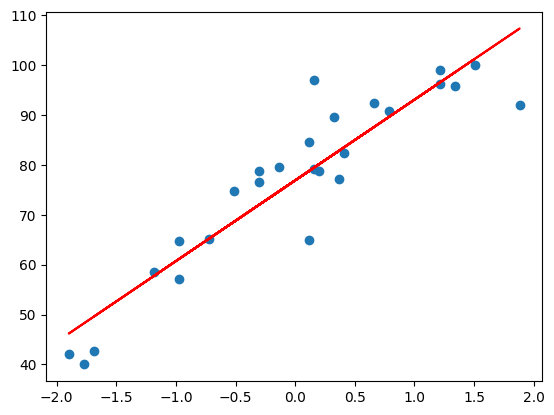

In [164]:
plt.scatter(X_train,y_train)
plt.plot(X_train , regression.predict(X_train), "r")
plt.show()

In [165]:
# 20 saat çalışmış bir insanın notunu bulalım. X=20 , y= ?

In [166]:
regression.predict([[20]]) # çıktı ---> array([427.04971807]) // Böyle bir not imkansız. Standart scaler ile vermem lazım!

array([400.47973694])

In [167]:
regression.predict(scaler.transform([[20]]))

c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([84.70590731])

In [168]:
regression.predict(scaler.transform([[10]])) # 10 saat çalışan biri bu notu alırmış

c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([62.05187491])

In [180]:
regression.predict(scaler.transform([[25]]))

c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([96.0329235])

In [170]:
# prediction with test data

In [171]:
y_pred_test = regression.predict(X_test) # Bu tahminimiz

In [172]:
y_test # Bu da gerçekler

25    42.4
14    86.6
30    91.5
16    57.2
24    51.2
20    49.0
19    84.7
Name: Exam Score, dtype: float64

In [173]:
# şimdi tahminlerimizle gerçekleri kıyaslayalım...

In [174]:
from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score

In [175]:
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)

print("mse: ", mse)
print("mae: ", mae)
print("rmse: ", rmse)

mse:  29.45839048833392
mae:  4.054868128856142
rmse:  5.427558427906043


In [176]:
# Farklı bir algoritmada model oluşturduğumuzda onun rmse'si daha düşük çıktığında bu daha iyi olabilir diyebiliriz model için. Kıyaslarken mantıklı!!!
# ama tek model üzerinden yorum yapacaksak r2_score kullanmak daha mantıklı bizim için !!!!

In [181]:
r2 = r2_score(y_test,y_pred_test)
print("r2 score: ", r2) # ---> %91 oranında tahminimiz doğru çıkmış...

r2 score:  0.9196596206825491


In [178]:
adj_r2 = 1 - ((1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)) # ---> adjusted r2 score sklearn'de yok!!!!

In [179]:
adj_r2 # --> bir feature daha eklediğimizde adjusted r2 score'a bakmamız faydalı olacaktır!

0.903591544819059